In [1]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

class PNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4,8)
    self.fc2 = nn.Linear(8,4)
    self.fc3 = nn.Linear(4,2)

  def forward(self,a):
    a = self.fc1(a)
    a = torch.relu(a)
    a = self.fc2(a)
    a = torch.relu(a)
    a = self.fc3(a)
    return a

class PG():
  def __init__(self,model,env,gamma,lr=0.001):
    self.model = model
    self.env = env
    self.optimizer = optim.Adam(self.model.parameters(),lr=lr)
    self.gamma = gamma
    self.device = torch.device( "cuda" if torch.cuda.is_available() else "cpu" )
    self.model.to(self.device)

  def get_return(self, rewards):
    G = [0] * len(rewards)
    return_ = 0

    for i in reversed(range(len(rewards))):
        return_ = rewards[i] + self.gamma * return_
        G[i] = return_

    return G

  def do_episode(self):
    state_list = []
    reward_list = []
    action_list = []
    log_prob_list = []
    terminated, truncated = False, False
    obs, _ = self.env.reset()
    while not (terminated or truncated):
      state_list.append(obs)
      obs = torch.tensor(obs, dtype=torch.float32, device=self.device)
      logits = self.model(obs)
      dist = torch.distributions.Categorical(logits=logits)
      action = dist.sample()
      log_prob = dist.log_prob(action)
      obs, reward, terminated, truncated, _ = self.env.step(action.item())

      reward_list.append(reward)
      action_list.append(action)
      log_prob_list.append(log_prob)
    G = self.get_return(reward_list)

    loss = 0

    G_tensor = torch.tensor(G, dtype=torch.float32,device=self.device)
    log_prob_tensor = torch.stack(log_prob_list)

    loss = -torch.sum(log_prob_tensor*G_tensor)

    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()
    return sum(reward_list)

  def train(self,num_episode):
    rewards = []
    for i in range(num_episode):
      rewards.append(self.do_episode())
    rewards_numpy = np.array(rewards)
    window_size = 5
    moving_average = np.convolve(rewards_numpy, np.ones(window_size)/window_size, mode='valid')
    return moving_average

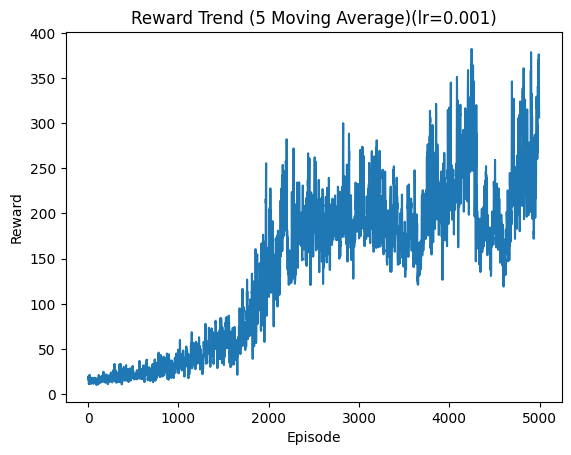

In [3]:
pg = PG(PNetwork(),gym.make('CartPole-v1',render_mode='rgb_array'),0.9)
history = pg.train(5000)

plt.title("Reward Trend (5 Moving Average)(lr=0.001)")
plt.plot(history)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

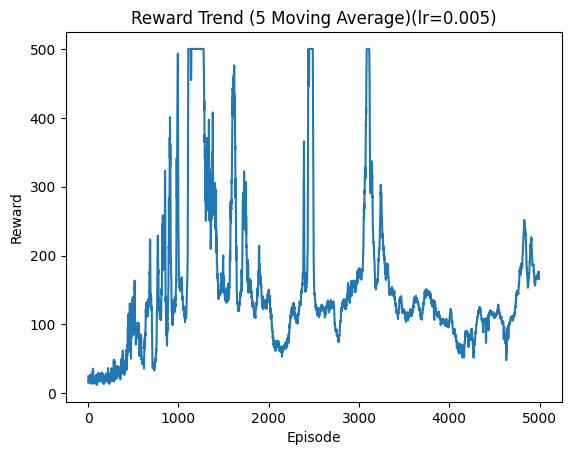

In [6]:
pg = PG(PNetwork(),gym.make('CartPole-v1',render_mode='rgb_array'),0.9,lr=0.005)
history = pg.train(5000)

plt.title("Reward Trend (5 Moving Average)(lr=0.005)")
plt.plot(history)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()

In [8]:
pg2 = PG(PNetwork(),gym.make('CartPole-v1',render_mode='rgb_array'),0.9)
pg2.train(4800)

array([ 21.8,  25. ,  23. , ..., 189. , 181. , 125.6])

In [9]:
import imageio

def record_agent(model, device, filename="agent.gif"):
    env = gym.make("CartPole-v1", render_mode="rgb_array")

    obs, _ = env.reset()

    frames = []

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # 현재 상태를 모델에 입력
        obs_tensor = torch.tensor(
            obs,
            dtype=torch.float32,
            device=device
        )

        # 평가에서는 gradient 필요 없음
        with torch.no_grad():
            logits = model(obs_tensor)

        # 가장 확률이 높은 행동 선택
        action = torch.argmax(logits).item()

        # 행동
        obs, reward, terminated, truncated, _ = env.step(action)

        # 현재 화면 저장
        frame = env.render()
        frames.append(frame)

    env.close()

    # GIF 저장
    imageio.mimsave(
        filename,
        frames,
        fps=30
    )

record_agent(
    pg2.model,
    pg2.device,
    "cartpole_agent.gif"
)

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [10]:
record_agent(pg.model,pg.device,"cartpole_agent1(lr005).gif")